# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves. Thanks [Yandex Data School Analysis](https://github.com/yandexdataschool/Practical_DL/blob/fall21/week03_convnets/seminar_pytorch.ipynb) for this work!

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

![image](https://github.com/yandexdataschool/Practical_DL/raw/fall21/week03_convnets/cifar10.jpg)

In [5]:
# when running in colab, un-comment this
!git clone https://huggingface.co/datasets/uoft-cs/cifar10


Cloning into 'cifar10'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 59 (delta 0), reused 0 (delta 0), pack-reused 58 (from 1)
Receiving objects: 100% (59/59), 13.25 KiB | 13.25 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Filtering content: 100% (2/2), 136.99 MiB | 1.59 MiB/s, done.


In [1]:
from datasets import load_dataset
import numpy as np
import os

def load_cifar10(data_dir="cifar_data"):
    """
    Загружает CIFAR-10 из локальной папки с помощью библиотеки datasets.
    Ожидается, что в папке data_dir находится файл cifar-10-python.tar.gz.
    Если файла нет, загрузка произойдёт напрямую с Hugging Face Hub.
    """
    # Проверяем наличие локального архива
    local_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
    if os.path.isfile(local_file):
        print(f"Загружаем из локального файла: {local_file}")
        dataset = load_dataset("uoft-cs/cifar10", "plain_text", data_files=local_file)
    else:
        print("Локальный файл не найден, загружаем из интернета...")
        dataset = load_dataset("uoft-cs/cifar10", "plain_text")
    
    # Извлекаем изображения и метки
    X_train = np.array([np.array(img) for img in dataset['train']['img']])
    y_train = np.array(dataset['train']['label'])
    X_test = np.array([np.array(img) for img in dataset['test']['img']])
    y_test = np.array(dataset['test']['label'])
    
    # Отделяем валидационную выборку (5000 примеров от тренировочной)
    val_size = 5000
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# Использование
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape, y_train.shape)   # (45000, 32, 32, 3) (45000,)
print(X_val.shape, y_val.shape)       # (5000, 32, 32, 3) (5000,)
print(X_test.shape, y_test.shape)     # (10000, 32, 32, 3) (10000,)

Локальный файл не найден, загружаем из интернета...


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

(45000, 32, 32, 3) (45000,)
(5000, 32, 32, 3) (5000,)
(10000, 32, 32, 3) (10000,)


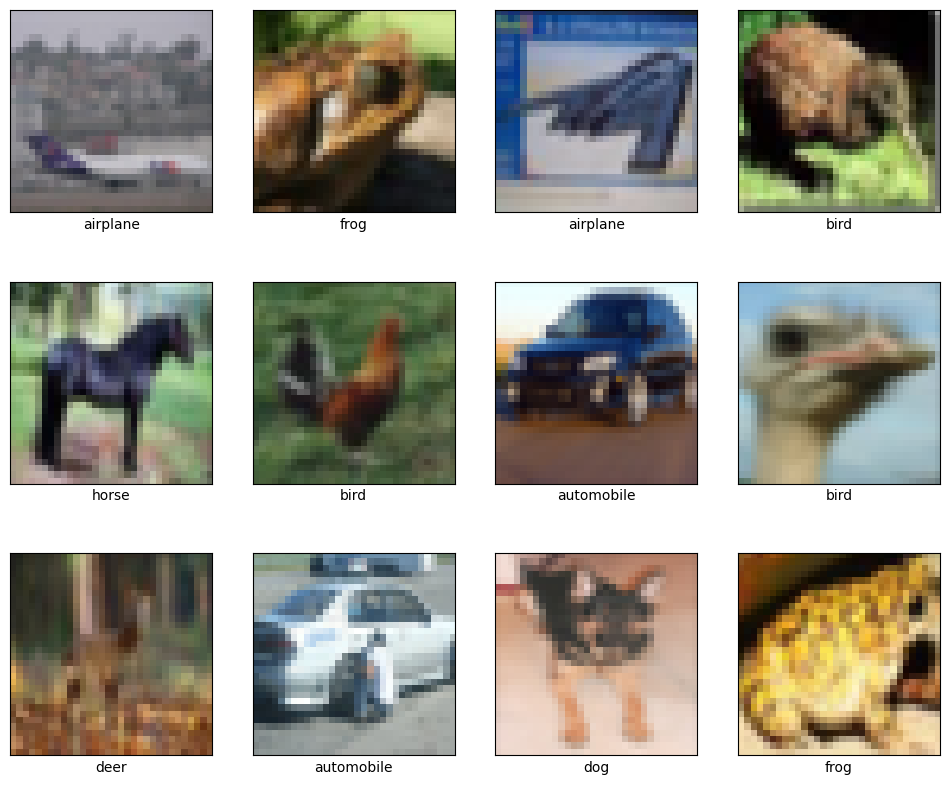

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12, 10])
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.xlabel(class_names[y_train[i]])
    # Никакого transpose! Просто X_train[i]
    plt.imshow(X_train[i])
    plt.xticks([])
    plt.yticks([])
plt.show()

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

In [19]:
import torch, torch.nn as nn
import torch.nn.functional as F

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

Let's start with a dense network for our baseline:

In [20]:
model = nn.Sequential()

# reshape from "images" to flat vectors
model.add_module('flatten', Flatten())

# dense "head"
model.add_module('dense1', nn.Linear(3 * 32 * 32, 64))
model.add_module('dense1_relu', nn.ReLU())
model.add_module('dense2_logits', nn.Linear(64, 10)) # logits for 10 classes

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [21]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [22]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(56.2071, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [23]:
# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [24]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

In [25]:
import time
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())
        
    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))

    
    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 100 took 0.910s
  training loss (in-iteration): 	4580.421387
  validation accuracy: 			8.98 %
Epoch 2 of 100 took 0.932s
  training loss (in-iteration): 	2.302802
  validation accuracy: 			8.98 %
Epoch 3 of 100 took 0.893s
  training loss (in-iteration): 	2.302631
  validation accuracy: 			8.98 %
Epoch 4 of 100 took 0.883s
  training loss (in-iteration): 	2.302603
  validation accuracy: 			8.98 %
Epoch 5 of 100 took 0.892s
  training loss (in-iteration): 	2.302595
  validation accuracy: 			8.98 %
Epoch 6 of 100 took 0.931s
  training loss (in-iteration): 	2.302607
  validation accuracy: 			8.98 %
Epoch 7 of 100 took 0.893s
  training loss (in-iteration): 	2.302603
  validation accuracy: 			8.98 %
Epoch 8 of 100 took 0.874s
  training loss (in-iteration): 	2.302603
  validation accuracy: 			8.98 %
Epoch 9 of 100 took 0.885s
  training loss (in-iteration): 	2.302600
  validation accuracy: 			8.98 %
Epoch 10 of 100 took 0.881s
  training loss (in-iteration): 	2.302605
  validat

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [26]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)
    
print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		10.00 %
We need more magic! Follow instructons below


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [50]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
import time
import os


# Определяем устройство (GPU, если доступно)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используем устройство: {device}')

Используем устройство: cuda


In [ ]:
def load_cifar10(data_dir="cifar_data"):
    """
    Загружает CIFAR-10 с помощью библиотеки datasets.
    Если в data_dir есть файл cifar-10-python.tar.gz, используется он,
    иначе данные скачиваются из интернета.
    Возвращает (X_train, y_train, X_val, y_val, X_test, y_test).
    """
    local_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
    if os.path.isfile(local_file):
        print(f"Загружаем из локального файла: {local_file}")
        dataset = load_dataset("uoft-cs/cifar10", "plain_text", data_files=local_file)
    else:
        print("Локальный файл не найден, загружаем из интернета...")
        dataset = load_dataset("uoft-cs/cifar10", "plain_text")
    
    X_train = np.array([np.array(img) for img in dataset['train']['img']])
    y_train = np.array(dataset['train']['label'])
    X_test = np.array([np.array(img) for img in dataset['test']['img']])
    y_test = np.array(dataset['test']['label'])
    
    # Отделяем валидационную выборку (5000 примеров)
    val_size = 5000
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")
class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print("Формы данных:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

Локальный файл не найден, загружаем из интернета...
Формы данных:
X_train: (45000, 32, 32, 3) y_train: (45000,)
X_val:   (5000, 32, 32, 3) y_val:   (5000,)
X_test:  (10000, 32, 32, 3) y_test:  (10000,)


In [52]:
def create_small_cnn():
    """
    Архитектура:
    - Conv2d(3,10,3) + ReLU
    - MaxPool2d(2)
    - Flatten
    - Linear(2250,100) + ReLU
    - Dropout(0.1)
    - Linear(100,10)
    """
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Flatten(),
        nn.Linear(2250, 100),  # 15x15x10 = 2250
        nn.ReLU(),
        nn.Dropout(p=0.1),
        nn.Linear(100, 10)
    )
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")
model = create_small_cnn().to(device)

Используем устройство: cuda


In [53]:
loss_fn = nn.CrossEntropyLoss()

def compute_loss(X_batch, y_batch):
    logits = model(X_batch)
    return loss_fn(logits, y_batch)

opt = optim.Adam(model.parameters())   # lr=0.001 по умолчанию

In [54]:
num_epochs = 100
batch_size = 50

train_loss = []
val_accuracy = []

for epoch in range(num_epochs):
    start_time = time.time()
    
    # === Обучение ===
    model.train(True)
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # Преобразование: каналы на второе место (N, C, H, W) и нормализация [0,1]
        X_tensor = torch.as_tensor(X_batch, dtype=torch.float32, device=device).permute(0, 3, 1, 2) / 255.0
        y_tensor = torch.as_tensor(y_batch, dtype=torch.int64, device=device)
        
        loss = compute_loss(X_tensor, y_tensor)
        loss.backward()
        opt.step()
        opt.zero_grad()
        
        train_loss.append(loss.item())
    
    # === Валидация ===
    model.train(False)
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size, shuffle=False):
        X_tensor = torch.as_tensor(X_batch, dtype=torch.float32, device=device).permute(0, 3, 1, 2) / 255.0
        y_tensor = torch.as_tensor(y_batch, dtype=torch.int64, device=device)
        
        with torch.no_grad():
            logits = model(X_tensor)
            y_pred = logits.max(1)[1].cpu().numpy()
        
        val_accuracy.append(np.mean(y_batch == y_pred))
    
    # === Логирование ===
    epoch_time = time.time() - start_time
    batches_per_epoch = len(X_train) // batch_size
    train_loss_epoch = np.mean(train_loss[-batches_per_epoch:])
    val_batches = len(X_val) // batch_size
    val_acc_epoch = np.mean(val_accuracy[-val_batches:]) * 100
    
    print(f"Epoch {epoch+1:3d}/{num_epochs} | {epoch_time:.2f}s | "
          f"train loss: {train_loss_epoch:.4f} | val accuracy: {val_acc_epoch:.2f}%")


Epoch   1/100 | 2.37s | train loss: 1.7955 | val accuracy: 44.78%
Epoch   2/100 | 2.04s | train loss: 1.5109 | val accuracy: 48.86%
Epoch   3/100 | 1.91s | train loss: 1.4016 | val accuracy: 50.88%
Epoch   4/100 | 2.05s | train loss: 1.3318 | val accuracy: 52.68%
Epoch   5/100 | 2.04s | train loss: 1.2739 | val accuracy: 55.16%
Epoch   6/100 | 2.06s | train loss: 1.2391 | val accuracy: 56.44%
Epoch   7/100 | 2.04s | train loss: 1.2015 | val accuracy: 57.24%
Epoch   8/100 | 2.04s | train loss: 1.1752 | val accuracy: 57.82%
Epoch   9/100 | 2.06s | train loss: 1.1505 | val accuracy: 56.90%
Epoch  10/100 | 2.01s | train loss: 1.1235 | val accuracy: 55.76%
Epoch  11/100 | 2.06s | train loss: 1.1074 | val accuracy: 58.54%
Epoch  12/100 | 2.04s | train loss: 1.0883 | val accuracy: 58.80%
Epoch  13/100 | 2.05s | train loss: 1.0704 | val accuracy: 58.08%
Epoch  14/100 | 2.04s | train loss: 1.0574 | val accuracy: 59.30%
Epoch  15/100 | 2.04s | train loss: 1.0375 | val accuracy: 58.52%
Epoch  16/

```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [56]:
def create_bn_cnn():
    model = nn.Sequential(
        nn.Conv2d(3, 10, kernel_size=3),   # (32,32,3) -> (30,30,10)
        nn.BatchNorm2d(10),                # батч-норм для свёрточного слоя
        nn.ReLU(),
        nn.MaxPool2d(2),                   # (30,30) -> (15,15)
        nn.Flatten(),
        nn.Linear(2250, 100),
        nn.BatchNorm1d(100),               # батч-норм для полносвязного слоя
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(100, 10)
    )
    return model

In [57]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
import time
import os

# ---------- Загрузка данных (та же, что и раньше) ----------
def load_cifar10(data_dir="cifar_data"):
    local_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
    if os.path.isfile(local_file):
        dataset = load_dataset("uoft-cs/cifar10", "plain_text", data_files=local_file)
    else:
        dataset = load_dataset("uoft-cs/cifar10", "plain_text")
    
    X_train = np.array([np.array(img) for img in dataset['train']['img']])
    y_train = np.array(dataset['train']['label'])
    X_test = np.array([np.array(img) for img in dataset['test']['img']])
    y_test = np.array(dataset['test']['label'])
    
    val_size = 5000
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

# ---------- Генератор мини-батчей ----------
def iterate_minibatches(X, y, batch_size, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)
    for start_idx in range(0, len(X) - batch_size + 1, batch_size):
        excerpt = indices[start_idx:start_idx + batch_size]
        yield X[excerpt], y[excerpt]

# ---------- Устройство ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

# ---------- Модель с BatchNorm ----------
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(2250, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
).to(device)

# ---------- Функция потерь и оптимизатор ----------
loss_fn = nn.CrossEntropyLoss()

def compute_loss(X_batch, y_batch):
    logits = model(X_batch)
    return loss_fn(logits, y_batch)

opt = optim.Adam(model.parameters())   # lr=0.001 по умолчанию

# ---------- Обучение ----------
num_epochs = 100
batch_size = 50

train_loss = []
val_accuracy = []

for epoch in range(num_epochs):
    start_time = time.time()
    
    # Обучение
    model.train()
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        X_tensor = torch.as_tensor(X_batch, dtype=torch.float32, device=device).permute(0, 3, 1, 2) / 255.0
        y_tensor = torch.as_tensor(y_batch, dtype=torch.int64, device=device)
        
        loss = compute_loss(X_tensor, y_tensor)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())
    
    # Валидация
    model.eval()
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size, shuffle=False):
        X_tensor = torch.as_tensor(X_batch, dtype=torch.float32, device=device).permute(0, 3, 1, 2) / 255.0
        y_tensor = torch.as_tensor(y_batch, dtype=torch.int64, device=device)
        with torch.no_grad():
            logits = model(X_tensor)
            y_pred = logits.max(1)[1].cpu().numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))
    
    # Логи
    epoch_time = time.time() - start_time
    batches_per_epoch = len(X_train) // batch_size
    train_loss_epoch = np.mean(train_loss[-batches_per_epoch:])
    val_batches = len(X_val) // batch_size
    val_acc_epoch = np.mean(val_accuracy[-val_batches:]) * 100
    
    print(f"Epoch {epoch+1:3d}/{num_epochs} | {epoch_time:.2f}s | "
          f"train loss: {train_loss_epoch:.4f} | val accuracy: {val_acc_epoch:.2f}%")

# ---------- Финальный тест ----------
model.eval()
test_correct = 0
for X_batch, y_batch in iterate_minibatches(X_test, y_test, batch_size, shuffle=False):
    X_tensor = torch.as_tensor(X_batch, dtype=torch.float32, device=device).permute(0, 3, 1, 2) / 255.0
    with torch.no_grad():
        logits = model(X_tensor)
        y_pred = logits.max(1)[1].cpu().numpy()
    test_correct += np.sum(y_pred == y_batch)
test_accuracy = test_correct / len(X_test) * 100
print(f"\nТестовая точность: {test_accuracy:.2f}%")

Используем устройство: cuda
Epoch   1/100 | 2.61s | train loss: 1.3756 | val accuracy: 54.64%
Epoch   2/100 | 2.46s | train loss: 1.1066 | val accuracy: 58.62%
Epoch   3/100 | 2.29s | train loss: 0.9938 | val accuracy: 62.26%
Epoch   4/100 | 2.45s | train loss: 0.9057 | val accuracy: 63.00%
Epoch   5/100 | 2.44s | train loss: 0.8401 | val accuracy: 54.86%
Epoch   6/100 | 2.45s | train loss: 0.7773 | val accuracy: 62.66%
Epoch   7/100 | 1.99s | train loss: 0.7195 | val accuracy: 60.52%
Epoch   8/100 | 2.50s | train loss: 0.6676 | val accuracy: 63.50%
Epoch   9/100 | 1.87s | train loss: 0.6254 | val accuracy: 61.48%
Epoch  10/100 | 2.46s | train loss: 0.5828 | val accuracy: 62.58%
Epoch  11/100 | 2.46s | train loss: 0.5401 | val accuracy: 59.14%
Epoch  12/100 | 2.47s | train loss: 0.5097 | val accuracy: 62.54%
Epoch  13/100 | 2.44s | train loss: 0.4770 | val accuracy: 63.14%
Epoch  14/100 | 2.45s | train loss: 0.4537 | val accuracy: 60.50%
Epoch  15/100 | 2.49s | train loss: 0.4287 | val


```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import time
import os
from datasets import load_dataset   # Hugging Face datasets

In [73]:
means = np.array([0.4914, 0.4822, 0.4465])
stds  = np.array([0.2023, 0.1994, 0.2010])

# Трансформация для обучения (с аугментацией)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation([-30, 30]),
    transforms.ToTensor(),                     # PIL -> тензор [0,1]
    transforms.Normalize(means, stds)          # стандартизация
])

In [74]:
def load_cifar10(data_dir="cifar_data"):
    """
    Загружает CIFAR-10 с помощью библиотеки datasets.
    Если в data_dir есть файл cifar-10-python.tar.gz, используется он,
    иначе данные скачиваются из интернета.
    Возвращает (X_train, y_train, X_val, y_val, X_test, y_test).
    """
    local_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
    if os.path.isfile(local_file):
        print(f"Загружаем из локального файла: {local_file}")
        dataset = load_dataset("uoft-cs/cifar10", "plain_text", data_files=local_file)
    else:
        print("Локальный файл не найден, загружаем из интернета...")
        dataset = load_dataset("uoft-cs/cifar10", "plain_text")
    
    X_train = np.array([np.array(img) for img in dataset['train']['img']])
    y_train = np.array(dataset['train']['label'])
    X_test = np.array([np.array(img) for img in dataset['test']['img']])
    y_test = np.array(dataset['test']['label'])
    
    # Отделяем валидационную выборку (5000 примеров)
    val_size = 5000
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")
class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print("Формы данных:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

Локальный файл не найден, загружаем из интернета...
Формы данных:
X_train: (45000, 32, 32, 3) y_train: (45000,)
X_val:   (5000, 32, 32, 3) y_val:   (5000,)
X_test:  (10000, 32, 32, 3) y_test:  (10000,)


In [75]:
means = np.array([0.4914, 0.4822, 0.4465])
stds  = np.array([0.2023, 0.1994, 0.2010])

# Трансформация для обучения (с аугментацией)
transform_train = transforms.Compose([
    transforms.ToTensor(),                     # (H,W,C) uint8 -> (C,H,W) float32 [0,1]
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation([-30, 30]),
    transforms.Normalize(means, stds)          # стандартизация
])

# Трансформация для валидации / теста (без аугментации)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds)
])


In [76]:
class CIFARDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images          # numpy (N, H, W, C) uint8
        self.labels = labels          # numpy (N,)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]        # (32, 32, 3) uint8
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Создаём обучающий, валидационный и тестовый датасеты
train_dataset = CIFARDataset(X_train, y_train, transform=transform_train)
val_dataset   = CIFARDataset(X_val,   y_val,   transform=transform_test)
test_dataset  = CIFARDataset(X_test,  y_test,  transform=transform_test)

In [77]:
batch_size = 50   # или 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

In [81]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(2250, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
).to(device)


loss_fn = nn.CrossEntropyLoss()

def compute_loss(X, y):
    return loss_fn(model(X), y)

opt = optim.Adam(model.parameters())   # lr = 0.001 по умолчанию

Устройство: cuda


In [80]:
num_epochs = 100
train_loss_log = []
val_accuracy_log = []

for epoch in range(num_epochs):
    start_time = time.time()

    # --- Тренировка ---
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()

        train_loss_log.append(loss.item())

    # --- Валидация ---
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            y_pred = logits.argmax(dim=1).cpu().numpy()
            y_true = y_batch.cpu().numpy()
            val_accuracy_log.append(np.mean(y_true == y_pred))

    # --- Логирование ---
    epoch_time = time.time() - start_time
    avg_train_loss = np.mean(train_loss_log[-len(train_loader):])
    avg_val_acc = np.mean(val_accuracy_log[-len(val_loader):]) * 100

    print(f"Epoch {epoch+1:3d}/{num_epochs} | {epoch_time:.2f}s | "
          f"loss: {avg_train_loss:.4f} | val accuracy: {avg_val_acc:.2f}%")


Epoch   1/100 | 7.83s | loss: 1.6612 | val accuracy: 50.36%
Epoch   2/100 | 7.58s | loss: 1.4934 | val accuracy: 54.10%
Epoch   3/100 | 7.55s | loss: 1.4337 | val accuracy: 56.14%
Epoch   4/100 | 7.37s | loss: 1.3966 | val accuracy: 56.96%
Epoch   5/100 | 7.08s | loss: 1.3753 | val accuracy: 58.56%
Epoch   6/100 | 7.16s | loss: 1.3541 | val accuracy: 58.18%
Epoch   7/100 | 7.80s | loss: 1.3281 | val accuracy: 58.96%
Epoch   8/100 | 7.44s | loss: 1.3237 | val accuracy: 58.50%
Epoch   9/100 | 7.26s | loss: 1.3100 | val accuracy: 60.14%
Epoch  10/100 | 7.17s | loss: 1.2984 | val accuracy: 60.10%
Epoch  11/100 | 7.23s | loss: 1.2961 | val accuracy: 61.38%
Epoch  12/100 | 7.30s | loss: 1.2863 | val accuracy: 61.34%
Epoch  13/100 | 7.40s | loss: 1.2791 | val accuracy: 61.74%
Epoch  14/100 | 7.18s | loss: 1.2742 | val accuracy: 60.54%
Epoch  15/100 | 7.19s | loss: 1.2638 | val accuracy: 62.06%
Epoch  16/100 | 7.41s | loss: 1.2577 | val accuracy: 62.40%
Epoch  17/100 | 7.08s | loss: 1.2525 | v

When testing, we don't need random crops, just normalize with same statistics.

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.
 
## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons, 
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.
 
   
### Data augmemntation
   * getting 5x as large dataset for free is a great 
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import time
import os
from datasets import load_dataset   # Hugging Face datasets

# ------------------------------------------------------------
# 1. Загрузка CIFAR-10 (ваша функция)
# ------------------------------------------------------------
def load_cifar10(data_dir="cifar_data"):
    local_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
    if os.path.isfile(local_file):
        dataset = load_dataset("uoft-cs/cifar10", "plain_text", data_files=local_file)
    else:
        dataset = load_dataset("uoft-cs/cifar10", "plain_text")
    
    X_train = np.array([np.array(img) for img in dataset['train']['img']])
    y_train = np.array(dataset['train']['label'])
    X_test  = np.array([np.array(img) for img in dataset['test']['img']])
    y_test  = np.array(dataset['test']['label'])
    
    val_size = 5000
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

# ------------------------------------------------------------
# 2. Аугментации и нормализация
# ------------------------------------------------------------
means = [0.4914, 0.4822, 0.4465]
stds  = [0.2023, 0.1994, 0.2010]

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.Normalize(means, stds)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds)
])

# ------------------------------------------------------------
# 3. PyTorch Dataset
# ------------------------------------------------------------
class CIFARDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]   # (32,32,3) uint8
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = CIFARDataset(X_train, y_train, transform=transform_train)
val_dataset   = CIFARDataset(X_val,   y_val,   transform=transform_test)
test_dataset  = CIFARDataset(X_test,  y_test,  transform=transform_test)

# ------------------------------------------------------------
# 4. DataLoader'ы
# ------------------------------------------------------------
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

# ------------------------------------------------------------
# 5. Модель: усиленная CNN с BatchNorm
# ------------------------------------------------------------
class CIFAR10Net(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Блок 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)   # 32→16
        )
        # Блок 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)   # 16→8
        )
        # Блок 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)   # 8→4
        )
        # Глобальный средний пул + классификатор
        self.global_pool = nn.AdaptiveAvgPool2d(1)   # -> 256
        self.classifier = nn.Sequential(
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CIFAR10Net().to(device)

# ------------------------------------------------------------
# 6. Оптимизатор и планировщик
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
scheduler.verbose = True   # включить печать сообщений о снижении lr

# ------------------------------------------------------------
# 7. Цикл обучения с ранней остановкой
# ------------------------------------------------------------
num_epochs = 150
best_val_acc = 0.0
patience_early = 15      # если 15 эпох без улучшения – стоп
no_improve = 0

for epoch in range(num_epochs):
    start = time.time()
    
    # Обучение
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    
    # Валидация
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total * 100
    
    # Планировщик
    scheduler.step(val_acc)
    
    # Ранняя остановка
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        # Сохраняем лучшую модель
        torch.save(model.state_dict(), 'best_cifar10_model.pth')
    else:
        no_improve += 1
        if no_improve >= patience_early:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    epoch_time = time.time() - start
    print(f"Epoch {epoch+1:3d}/{num_epochs} | {epoch_time:.2f}s | "
          f"Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}% | Best: {best_val_acc:.2f}%")

# ------------------------------------------------------------
# 8. Оценка на тесте (загружаем лучшую модель)
# ------------------------------------------------------------
model.load_state_dict(torch.load('best_cifar10_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
test_acc = correct / total * 100
print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")

Epoch   1/150 | 20.31s | Train Loss: 1.4286 | Val Acc: 54.08% | Best: 54.08%
Epoch   2/150 | 18.08s | Train Loss: 1.0373 | Val Acc: 66.66% | Best: 66.66%
Epoch   3/150 | 17.52s | Train Loss: 0.8749 | Val Acc: 67.38% | Best: 67.38%
Epoch   4/150 | 17.51s | Train Loss: 0.7682 | Val Acc: 69.82% | Best: 69.82%
Epoch   5/150 | 17.42s | Train Loss: 0.6964 | Val Acc: 73.82% | Best: 73.82%
Epoch   6/150 | 17.98s | Train Loss: 0.6438 | Val Acc: 78.56% | Best: 78.56%
Epoch   7/150 | 17.93s | Train Loss: 0.5961 | Val Acc: 78.72% | Best: 78.72%
Epoch   8/150 | 18.35s | Train Loss: 0.5646 | Val Acc: 80.86% | Best: 80.86%
Epoch   9/150 | 18.65s | Train Loss: 0.5263 | Val Acc: 82.36% | Best: 82.36%
Epoch  10/150 | 18.97s | Train Loss: 0.5022 | Val Acc: 81.74% | Best: 82.36%
Epoch  11/150 | 18.88s | Train Loss: 0.4799 | Val Acc: 84.42% | Best: 84.42%
Epoch  12/150 | 19.08s | Train Loss: 0.4573 | Val Acc: 83.62% | Best: 84.42%
Epoch  13/150 | 32.67s | Train Loss: 0.4398 | Val Acc: 84.96% | Best: 84.96%

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import time
import os
from datasets import load_dataset   # Hugging Face datasets

# ------------------------------------------------------------
# 1. Загрузка CIFAR-10 (ваша функция)
# ------------------------------------------------------------
def load_cifar10(data_dir="cifar_data"):
    local_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
    if os.path.isfile(local_file):
        dataset = load_dataset("uoft-cs/cifar10", "plain_text", data_files=local_file)
    else:
        dataset = load_dataset("uoft-cs/cifar10", "plain_text")
    
    X_train = np.array([np.array(img) for img in dataset['train']['img']])
    y_train = np.array(dataset['train']['label'])
    X_test  = np.array([np.array(img) for img in dataset['test']['img']])
    y_test  = np.array(dataset['test']['label'])
    
    val_size = 5000
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

# ------------------------------------------------------------
# 2. Аугментации и нормализация
# ------------------------------------------------------------
means = [0.4914, 0.4822, 0.4465]
stds  = [0.2023, 0.1994, 0.2010]

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.Normalize(means, stds)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds)
])

# ------------------------------------------------------------
# 3. PyTorch Dataset
# ------------------------------------------------------------
class CIFARDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]   # (32,32,3) uint8
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = CIFARDataset(X_train, y_train, transform=transform_train)
val_dataset   = CIFARDataset(X_val,   y_val,   transform=transform_test)
test_dataset  = CIFARDataset(X_test,  y_test,  transform=transform_test)

# ------------------------------------------------------------
# 4. DataLoader'ы
# ------------------------------------------------------------
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

# ------------------------------------------------------------
# 5. Модель: усиленная CNN с BatchNorm
# ------------------------------------------------------------
class CIFAR10Net(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Блок 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)   # 32→16
        )
        # Блок 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)   # 16→8
        )
        # Блок 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)   # 8→4
        )
        # Глобальный средний пул + классификатор
        self.global_pool = nn.AdaptiveAvgPool2d(1)   # -> 256
        self.classifier = nn.Sequential(
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CIFAR10Net().to(device)

# ------------------------------------------------------------
# 8. Оценка на тесте (загружаем лучшую модель)
# ------------------------------------------------------------
model.load_state_dict(torch.load('best_cifar10_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
test_acc = correct / total * 100
print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")


correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
val_acc = correct / total * 100
print(f"\n🎯 Final Val Accuracy: {val_acc:.2f}%")


correct = 0
total = 0
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
train_acc = correct / total * 100
print(f"\n🎯 Final Train Accuracy: {train_acc:.2f}%")


🎯 Final Test Accuracy: 91.29%

🎯 Final Val Accuracy: 92.22%

🎯 Final Train Accuracy: 98.70%
